# 01 — Análise Exploratória de Dados

In [225]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Semente fixa: use em TODO ponto com aleatoriedade (split, modelos, CV).
RANDOM_STATE = 42

credit_record = Path("..") / "data" / "raw" / "credit_record.csv" 
application_record = Path("..") / "data" / "raw" / "application_record.csv"

credit_record = pd.read_csv(credit_record)
application_record = pd.read_csv(application_record)

df = pd.merge(credit_record, application_record, on="ID", how="inner")
df.head()
df.to_csv('../data/raw/df.csv', index=False)

RAW = Path("..") / "data" / "raw" / "df.csv"
PROCESSED = Path("..") / "data" / "processed"
TARGET = "COMPLIANCE"                                            

pd.set_option("display.max_columns", None)

In [226]:
df = pd.read_csv(RAW)
df.head()

,ID,MONTHS_BALANCE,STATUS,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,0,C,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008804,-1,C,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008804,-2,C,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
3,5008804,-3,C,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
4,5008804,-4,C,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0


## 1. Visão geral

_Dimensões, tipos e primeira impressão do dataset._

In [227]:
# Formato dos dados
df.shape

(777715, 20)

**Interpretação**

Há 777715 linhas e 20 colunas.
________________________________________________________________________________________________________________________________

In [228]:
# Tipos de dados
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 777715 entries, 0 to 777714
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   777715 non-null  int64  
 1   MONTHS_BALANCE       777715 non-null  int64  
 2   STATUS               777715 non-null  str    
 3   CODE_GENDER          777715 non-null  str    
 4   FLAG_OWN_CAR         777715 non-null  str    
 5   FLAG_OWN_REALTY      777715 non-null  str    
 6   CNT_CHILDREN         777715 non-null  int64  
 7   AMT_INCOME_TOTAL     777715 non-null  float64
 8   NAME_INCOME_TYPE     777715 non-null  str    
 9   NAME_EDUCATION_TYPE  777715 non-null  str    
 10  NAME_FAMILY_STATUS   777715 non-null  str    
 11  NAME_HOUSING_TYPE    777715 non-null  str    
 12  DAYS_BIRTH           777715 non-null  int64  
 13  DAYS_EMPLOYED        777715 non-null  int64  
 14  FLAG_MOBIL           777715 non-null  int64  
 15  FLAG_WORK_PHONE      777715 

**Interpretação**

Há valores nulos na coluna OCCUPATION_TYPE.
________________________________________________________________________________________________________________________________

In [229]:
# Tratando o tipo de dado da coluna CNT_FAM_MEMBERS
df.CNT_FAM_MEMBERS = df.CNT_FAM_MEMBERS.astype('int64')

In [230]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 777715 entries, 0 to 777714
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   777715 non-null  int64  
 1   MONTHS_BALANCE       777715 non-null  int64  
 2   STATUS               777715 non-null  str    
 3   CODE_GENDER          777715 non-null  str    
 4   FLAG_OWN_CAR         777715 non-null  str    
 5   FLAG_OWN_REALTY      777715 non-null  str    
 6   CNT_CHILDREN         777715 non-null  int64  
 7   AMT_INCOME_TOTAL     777715 non-null  float64
 8   NAME_INCOME_TYPE     777715 non-null  str    
 9   NAME_EDUCATION_TYPE  777715 non-null  str    
 10  NAME_FAMILY_STATUS   777715 non-null  str    
 11  NAME_HOUSING_TYPE    777715 non-null  str    
 12  DAYS_BIRTH           777715 non-null  int64  
 13  DAYS_EMPLOYED        777715 non-null  int64  
 14  FLAG_MOBIL           777715 non-null  int64  
 15  FLAG_WORK_PHONE      777715 

---

In [231]:
# Análise estatística
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
ID,777715.0,5078742.95,41804.42,5008804.0,5044568.5,5069530.0,5115551.0,5150487.0
MONTHS_BALANCE,777715.0,-19.37,14.08,-60.0,-29.0,-17.0,-8.0,0.0
CNT_CHILDREN,777715.0,0.43,0.75,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,777715.0,188534.80,101622.45,27000.0,121500.0,162000.0,225000.0,1575000.0
DAYS_BIRTH,777715.0,-16124.94,4104.30,-25152.0,-19453.0,-15760.0,-12716.0,-7489.0
DAYS_EMPLOYED,777715.0,57775.83,136471.74,-15713.0,-3292.0,-1682.0,-431.0,365243.0
FLAG_MOBIL,777715.0,1.00,0.00,1.0,1.0,1.0,1.0,1.0
FLAG_WORK_PHONE,777715.0,0.23,0.42,0.0,0.0,0.0,0.0,1.0
FLAG_PHONE,777715.0,0.30,0.46,0.0,0.0,0.0,1.0,1.0
FLAG_EMAIL,777715.0,0.09,0.29,0.0,0.0,0.0,0.0,1.0


**Interpretação**

Desvio padrão relativamente alto para a maioria das colunas.

Na coluna CNT_CHILDREN há um range de 0 a 19 filhos, o que afeta a coluna CNT_FAM_MEMBERS. Tratar antes de rodar modelos.

A coluna AMT_INCOME_TOTAL apresenta um máximo muito alto. Tratar antes de rodar modelos.

A coluna DAYS_EMPLOYED apresenta um valor máximo muito grande, equivalente a 1000 anos. Tratar antes de rodar modelos.

A coluna FLAG_MOBIL apresenta apenas 1 valor para todas as linhas. Pode ser excluída.

________________________________________________________________________________________________________________________________

In [232]:
# Analisando as primeiras linhas
df.head()

,ID,MONTHS_BALANCE,STATUS,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,0,C,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2
1,5008804,-1,C,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2
2,5008804,-2,C,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2
3,5008804,-3,C,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2
4,5008804,-4,C,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2


**Interpretação**

Há informações diferentes para mesmo ID. Agrupar por 'ID'.
________________________________________________________________________________________________________________________________

In [233]:
# Verificando os valores únicos de cada coluna
for col in df.columns:
    print(f"Coluna: {col}, Valores únicos: {df[col].nunique()}")

Coluna: ID, Valores únicos: 36457
Coluna: MONTHS_BALANCE, Valores únicos: 61
Coluna: STATUS, Valores únicos: 8
Coluna: CODE_GENDER, Valores únicos: 2
Coluna: FLAG_OWN_CAR, Valores únicos: 2
Coluna: FLAG_OWN_REALTY, Valores únicos: 2
Coluna: CNT_CHILDREN, Valores únicos: 9
Coluna: AMT_INCOME_TOTAL, Valores únicos: 265
Coluna: NAME_INCOME_TYPE, Valores únicos: 5
Coluna: NAME_EDUCATION_TYPE, Valores únicos: 5
Coluna: NAME_FAMILY_STATUS, Valores únicos: 5
Coluna: NAME_HOUSING_TYPE, Valores únicos: 6
Coluna: DAYS_BIRTH, Valores únicos: 7183
Coluna: DAYS_EMPLOYED, Valores únicos: 3640
Coluna: FLAG_MOBIL, Valores únicos: 1
Coluna: FLAG_WORK_PHONE, Valores únicos: 2
Coluna: FLAG_PHONE, Valores únicos: 2
Coluna: FLAG_EMAIL, Valores únicos: 2
Coluna: OCCUPATION_TYPE, Valores únicos: 18
Coluna: CNT_FAM_MEMBERS, Valores únicos: 10


**Interpretação**

Constata-se que a coluna FLAG_MOBIL contém apenas um valor para todas as linhas.

Colunas CODE_GENDER, FLAG_OWN_CAR, FLAG_OWN_REALTY, FLAG_WORK_PHONE, FLAG_PHONE e FLAG_EMAIL contém valores dicotômicos.
________________________________________________________________________________________________________________________________

In [234]:
# Verificando as colunas com valores dicotômicos
for col in df.columns:
  if df[col].nunique() == 2:
    print(f"{col} = {df[col].unique()}")

CODE_GENDER = <StringArray>
['M', 'F']
Length: 2, dtype: str
FLAG_OWN_CAR = <StringArray>
['Y', 'N']
Length: 2, dtype: str
FLAG_OWN_REALTY = <StringArray>
['Y', 'N']
Length: 2, dtype: str
FLAG_WORK_PHONE = [1 0]
FLAG_PHONE = [0 1]
FLAG_EMAIL = [0 1]


**Interpretação**

As colunas CODE_GENDER, FLAG_OWN_CAR e FLAG_OWN_REALTY podem ser binarizadas. 

As colunas FLAG_WORK_PHONE, FLAG_PHONE e FLAG_EMAIL já estão binarizadas.
________________________________________________________________________________________________________________________________

In [235]:
# Vericando valores da coluna OCCUPATION_TYPE
df['OCCUPATION_TYPE'].value_counts()

OCCUPATION_TYPE
Laborers                 131572
Core staff                77112
Sales staff               70362
Managers                  67738
Drivers                   47678
High skill tech staff     31768
Accountants               27223
Medicine staff            26691
Cooking staff             13416
Security staff            12400
Cleaning staff            11399
Private service staff      6714
Low-skill Laborers         3623
Secretaries                3149
Waiters/barmen staff       2557
HR staff                   1686
IT staff                   1319
Realty agents              1260
Name: count, dtype: int64

**Interpretação**

Nota-se que os valores não nulos se referem à cargos dos candidatos contratados.

Hipótese: valores nulos são de candidatos não contratados?
________________________________________________________________________________________________________________________________

In [236]:
# Verificando linhas duplicadas
df.duplicated().sum()

np.int64(0)

**Interpretação**

Não há linhas duplicadas.
________________________________________________________________________________________________________________________________

Criando a coluna COMPLIANCE a partir da coluna STATUS

Esta coluna mostra se o ciente é bom ou mal pagador através do critério padrão de risco.

1 - Mal Pagador: clientes que apresentam os indicadores 2, 3, 4 ou 5 em seu STATUS, demonstrando inadimplência grave, com atrasos maiores de 60 dias.

0 - Bom Pagador: clientes que apresentam os indicadores 0, 1, C ou X.

In [237]:
# Agrupando df por cliente

cliente = df.groupby('ID')['STATUS'].sum().reset_index()
cliente.head()

# Separando o status que identifica mal pagador (>=60 dias de atraso)
bad_status = {'2', '3', '4', '5'}

# Criando de uma coluna chamada COMPLIANCE que será preenchida com 0 ou 1
cliente['COMPLIANCE'] = cliente.STATUS.apply(lambda s: 1 if any(char in bad_status for char in str(s)) else 0)

# Excluindo da coluna STATUS, que não será mais utilizada
cliente.drop(columns='STATUS', inplace=True)

# Juntando os 2 dataframes
df = pd.merge(df, cliente, on='ID', how='inner')

df.COMPLIANCE.value_counts()

COMPLIANCE
0    757150
1     20565
Name: count, dtype: int64

## 2. Distribuição das variáveis

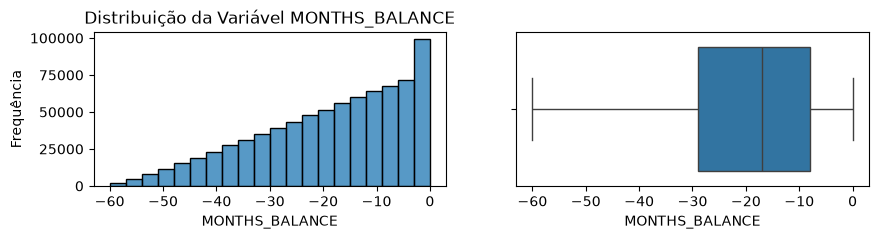

In [238]:
# Plotando distribuição e boxplot da coluna MONTHS_BALANCE

fig, axes = plt.subplots(1, 2, figsize=(10, 2))

sns.histplot(data=df.MONTHS_BALANCE, bins=20, ax=axes[0])
axes[0].set_title('Distribuição da Variável MONTHS_BALANCE')
axes[0].set_xlabel('MONTHS_BALANCE')
axes[0].set_ylabel('Frequência')

sns.boxplot(x='MONTHS_BALANCE', data=df, ax=axes[1]) 

plt.show()

**Interpretação:**

Mostra que há mais valores coletados quanto mais recente é o mês.

Não apresenta outliers.
________________________________________________________________________________________________________________________________

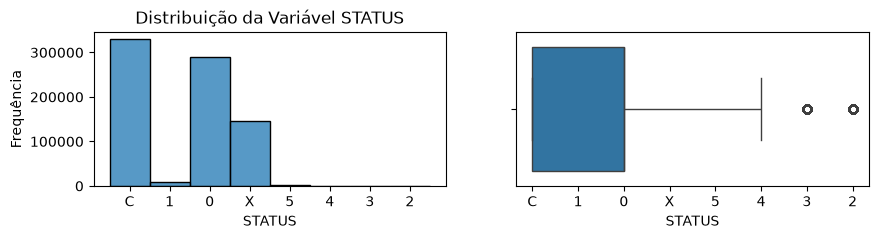

In [239]:
# Plotando distribuição e boxplot da coluna STATUS

fig, axes = plt.subplots(1, 2, figsize=(10, 2))

sns.histplot(data=df.STATUS, bins=20, ax=axes[0])
axes[0].set_title('Distribuição da Variável STATUS')
axes[0].set_xlabel('STATUS')
axes[0].set_ylabel('Frequência')

sns.boxplot(x='STATUS', data=df, ax=axes[1])    

plt.show()

**Interpretação**

A maior parte dos dados está no primeiro quartil.

Há outliers, porém são valores que não podem ser ignorados, pois são dados de operações vencidas.
________________________________________________________________________________________________________________________________

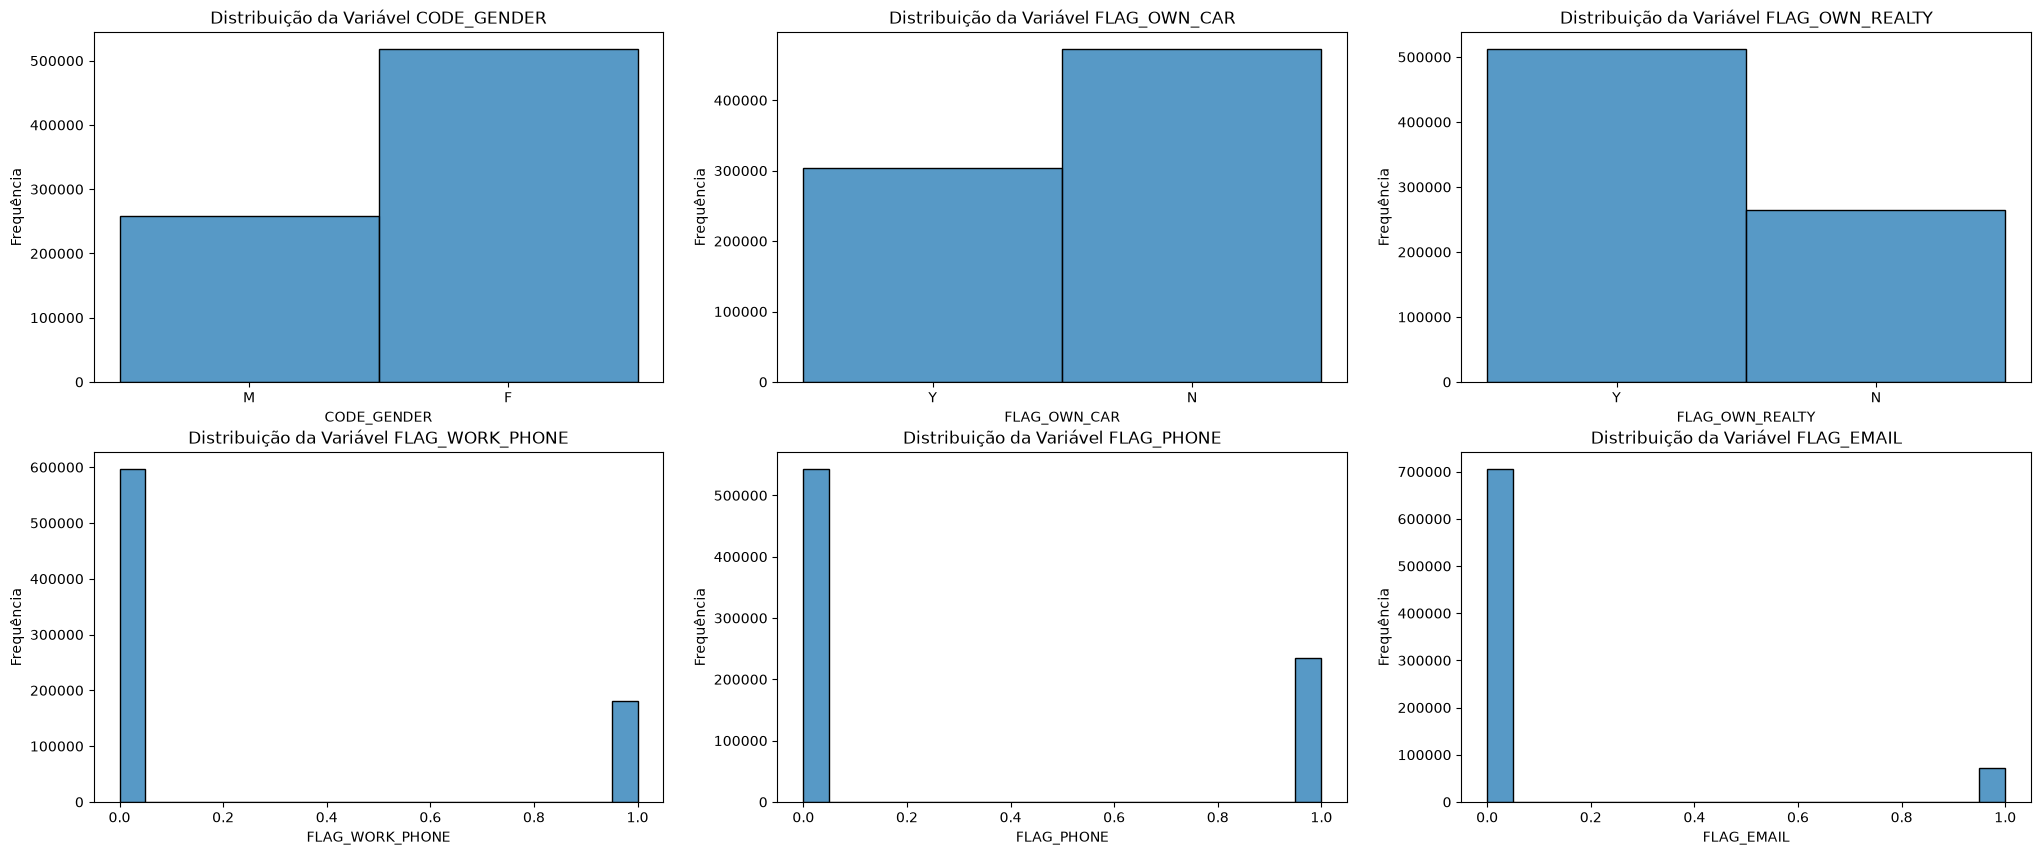

In [240]:
# Plotando distribuição para variáveis booleanas (CODE_GENDER, FLAG_OWN_CAR, FLAG_OWN_REALTY, FLAG_WORK_PHONE, FLAG_PHONE, FLAG_EMAIL)

fig, axes = plt.subplots(2, 3, figsize=(25, 10))

sns.histplot(data=df.CODE_GENDER, bins=20, ax=axes[0][0])
axes[0][0].set_title('Distribuição da Variável CODE_GENDER')
axes[0][0].set_xlabel('CODE_GENDER')
axes[0][0].set_ylabel('Frequência')

sns.histplot(data=df.FLAG_OWN_CAR, bins=20, ax=axes[0][1])
axes[0][1].set_title('Distribuição da Variável FLAG_OWN_CAR')
axes[0][1].set_xlabel('FLAG_OWN_CAR')
axes[0][1].set_ylabel('Frequência') 

sns.histplot(data=df.FLAG_OWN_REALTY, bins=20, ax=axes[0][2])
axes[0][2].set_title('Distribuição da Variável FLAG_OWN_REALTY')
axes[0][2].set_xlabel('FLAG_OWN_REALTY')
axes[0][2].set_ylabel('Frequência')

sns.histplot(data=df.FLAG_WORK_PHONE, bins=20, ax=axes[1][0])
axes[1][0].set_title('Distribuição da Variável FLAG_WORK_PHONE') 
axes[1][0].set_xlabel('FLAG_WORK_PHONE')
axes[1][0].set_ylabel('Frequência')

sns.histplot(data=df.FLAG_PHONE, bins=20, ax=axes[1][1])
axes[1][1].set_title('Distribuição da Variável FLAG_PHONE')
axes[1][1].set_xlabel('FLAG_PHONE')
axes[1][1].set_ylabel('Frequência')

sns.histplot(data=df.FLAG_EMAIL, bins=20, ax=axes[1][2])
axes[1][2].set_title('Distribuição da Variável FLAG_EMAIL')
axes[1][2].set_xlabel('FLAG_EMAIL')
axes[1][2].set_ylabel('Frequência')

plt.show()

**Interpretação**

Todos os gráficos mostraram que há mais dados em um grupo do que para outro.

________________________________________________________________________________________________________________________________

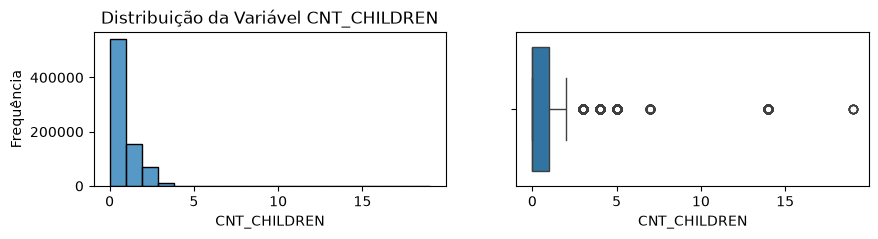

In [241]:
# Plotando distribuição e boxplot da coluna CNT_CHILDREN

fig, axes = plt.subplots(1, 2, figsize=(10, 2))

sns.histplot(data=df.CNT_CHILDREN, bins=20, ax=axes[0])
axes[0].set_title('Distribuição da Variável CNT_CHILDREN')
axes[0].set_xlabel('CNT_CHILDREN')
axes[0].set_ylabel('Frequência')

sns.boxplot(x='CNT_CHILDREN', data=df, ax=axes[1])    

plt.show()

**Interpretação**

Gráfico mostra assimetria à direita, com mais dados localizados na parte esquerda do gráfico.

Há outliers, porém não se sabe ainda se pode descartá-los ou não.
________________________________________________________________________________________________________________________________

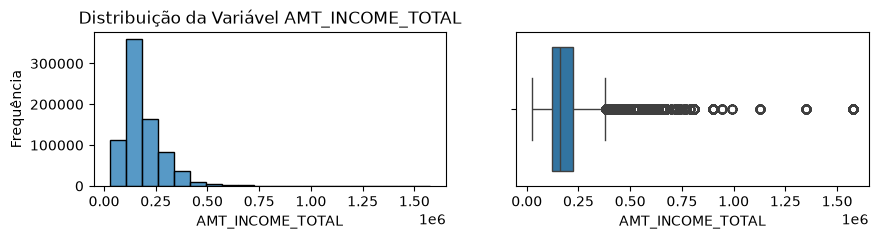

In [242]:
# Plotando distribuição e boxplot da coluna AMT_INCOME_TOTAL

fig, axes = plt.subplots(1, 2, figsize=(10, 2))

sns.histplot(data=df.AMT_INCOME_TOTAL, bins=20, ax=axes[0])
axes[0].set_title('Distribuição da Variável AMT_INCOME_TOTAL')
axes[0].set_xlabel('AMT_INCOME_TOTAL')
axes[0].set_ylabel('Frequência')

sns.boxplot(x='AMT_INCOME_TOTAL', data=df, ax=axes[1])    

plt.show()

**Interpretação**

Gráfico mostra assimetria à direita, com mais dados localizados na parte esquerda do gráfico.

Há outliers, porém não se sabe ainda se pode descartá-los ou não.
________________________________________________________________________________________________________________________________

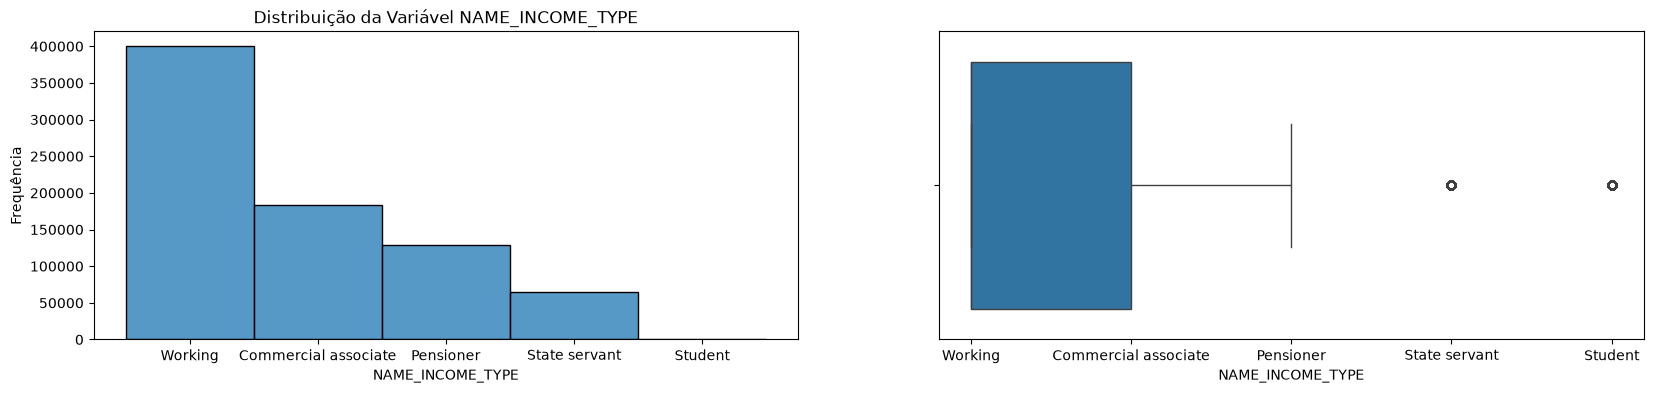

In [243]:
# Plotando distribuição e boxplot da coluna NAME_INCOME_TYPE

fig, axes = plt.subplots(1, 2, figsize=(20, 4))

sns.histplot(data=df.NAME_INCOME_TYPE, bins=20, ax=axes[0])
axes[0].set_title('Distribuição da Variável NAME_INCOME_TYPE')
axes[0].set_xlabel('NAME_INCOME_TYPE')
axes[0].set_ylabel('Frequência')

sns.boxplot(x='NAME_INCOME_TYPE', data=df, ax=axes[1])    

plt.show()

**Interpretação**

Gráfico mostra assimetria à direita, com mais dados localizados na parte esquerda do gráfico.

Há outliers, porém não se sabe ainda se pode descartá-los ou não.
________________________________________________________________________________________________________________________________

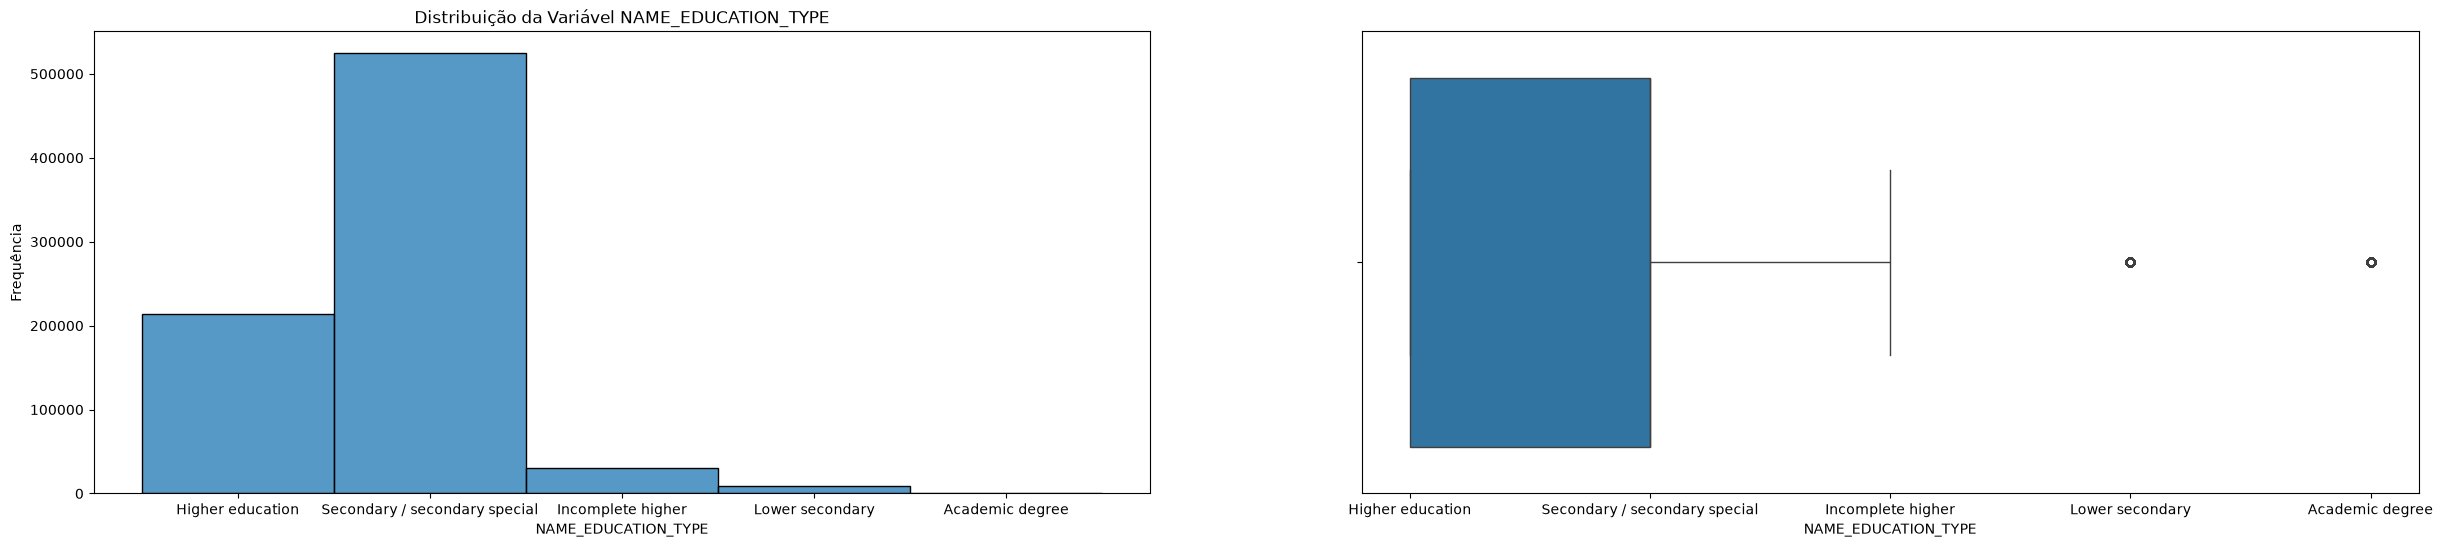

In [244]:
# Plotando distribuição e boxplot da coluna NAME_EDUCATION_TYPE

fig, axes = plt.subplots(1, 2, figsize=(30, 6))

sns.histplot(data=df.NAME_EDUCATION_TYPE, bins=20, ax=axes[0])
axes[0].set_title('Distribuição da Variável NAME_EDUCATION_TYPE')
axes[0].set_xlabel('NAME_EDUCATION_TYPE')
axes[0].set_ylabel('Frequência')

sns.boxplot(x='NAME_EDUCATION_TYPE', data=df, ax=axes[1])    

plt.show()

**Interpretação**

Gráfico mostra assimetria à direita, com mais dados localizados na parte esquerda do gráfico.

Há outliers, porém não se sabe ainda se pode descartá-los ou não.
________________________________________________________________________________________________________________________________

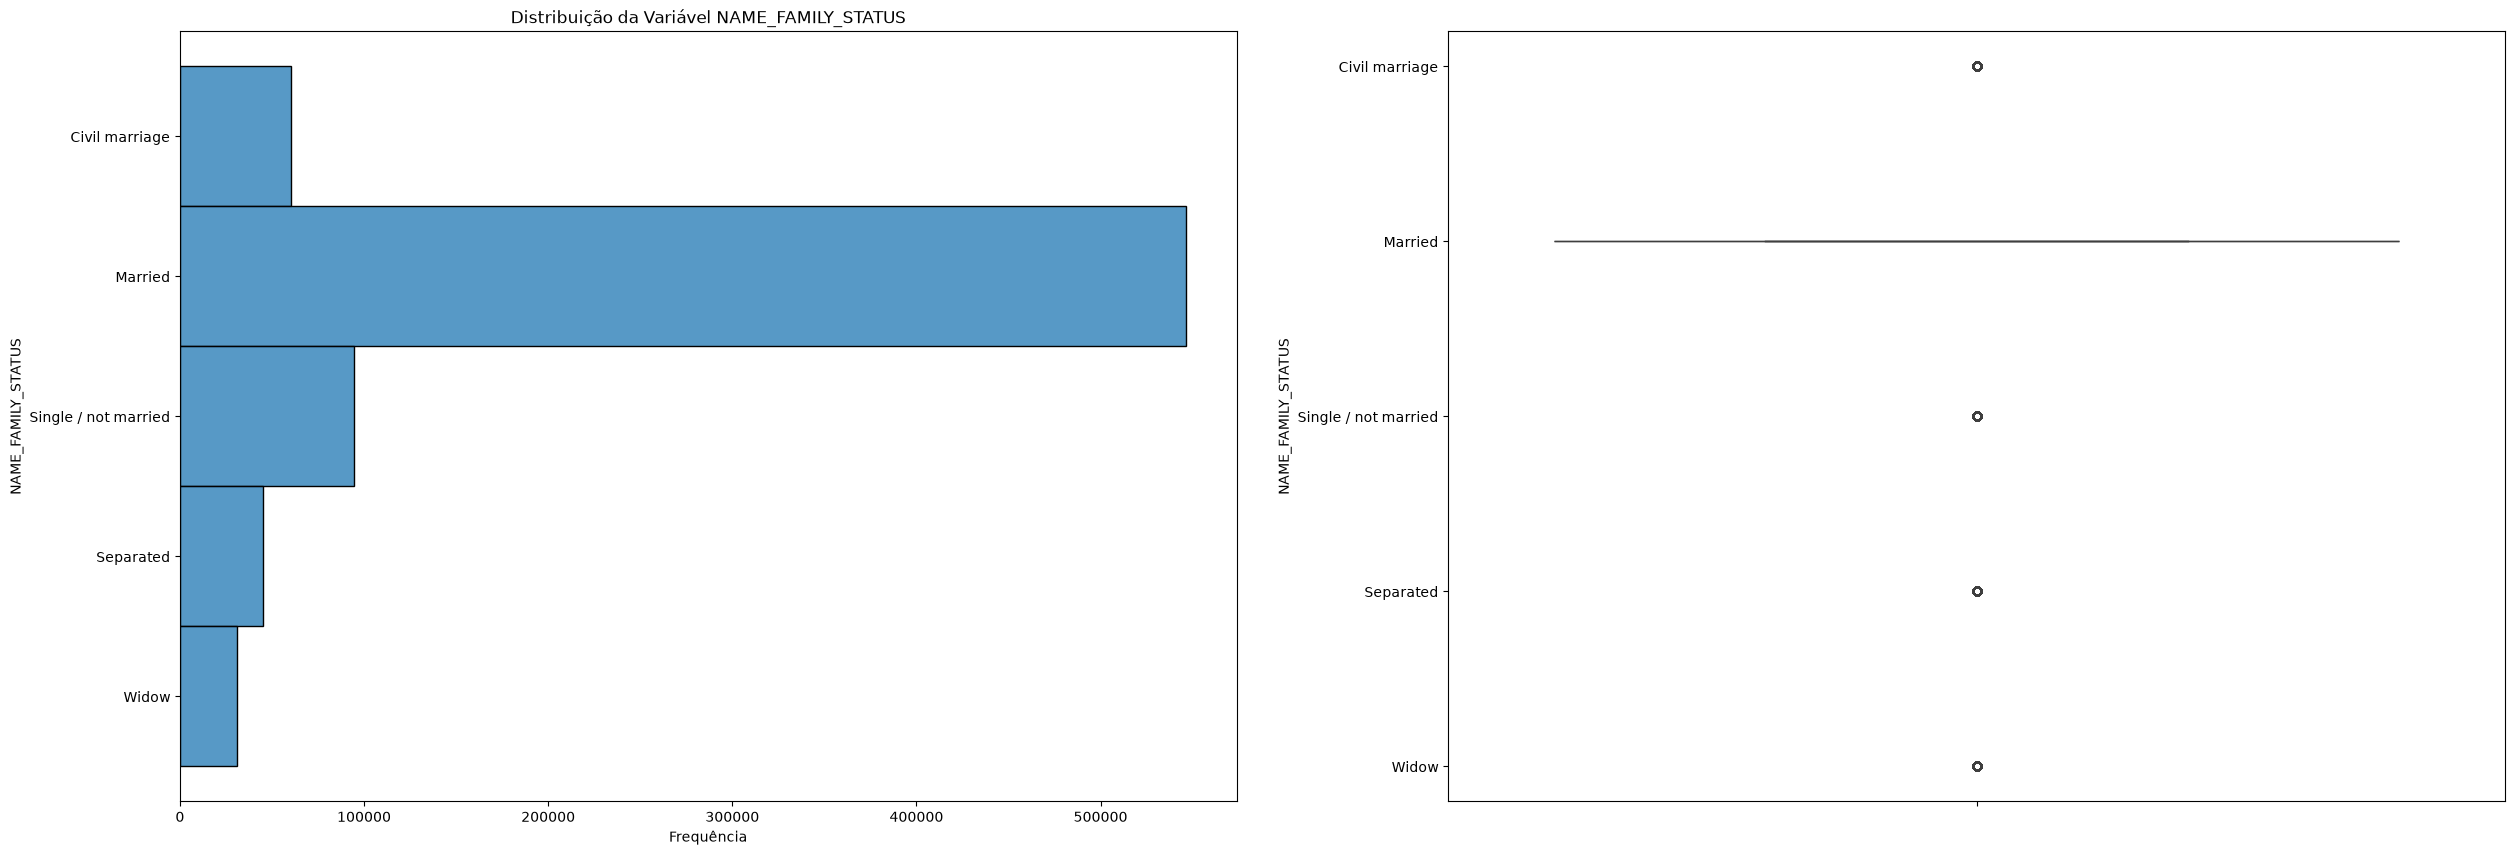

In [245]:
# Plotando distribuição e boxplot da coluna NAME_FAMILY_STATUS

fig, axes = plt.subplots(1, 2, figsize=(30, 10))

sns.histplot(y=df.NAME_FAMILY_STATUS, bins=20, ax=axes[0])
axes[0].set_title('Distribuição da Variável NAME_FAMILY_STATUS')
axes[0].set_ylabel('NAME_FAMILY_STATUS')
axes[0].set_xlabel('Frequência')

sns.boxplot(y='NAME_FAMILY_STATUS', data=df, ax=axes[1])    

plt.show()

**Interpretação**

Maior parte dos candidatos são casados.
________________________________________________________________________________________________________________________________

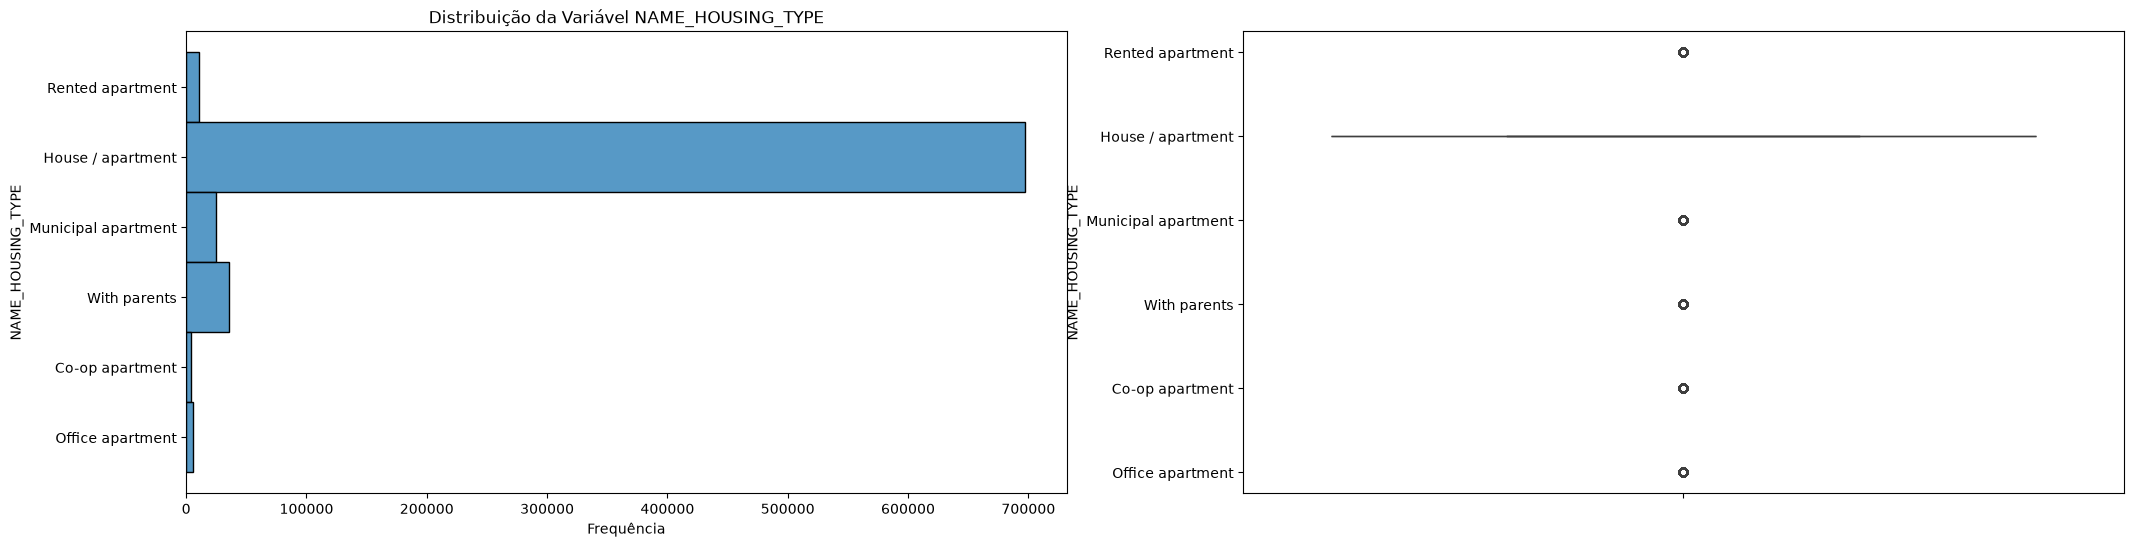

In [246]:
# Plotando distribuição e boxplot da coluna NAME_HOUSING_TYPE

fig, axes = plt.subplots(1, 2, figsize=(25, 6))

sns.histplot(y=df.NAME_HOUSING_TYPE, bins=20, ax=axes[0])
axes[0].set_title('Distribuição da Variável NAME_HOUSING_TYPE')
axes[0].set_ylabel('NAME_HOUSING_TYPE')
axes[0].set_xlabel('Frequência')

sns.boxplot(y='NAME_HOUSING_TYPE', data=df, ax=axes[1])    

plt.show()

**Interpretação**

Maior parte dos candidatos possuem casa/apartamento.
________________________________________________________________________________________________________________________________

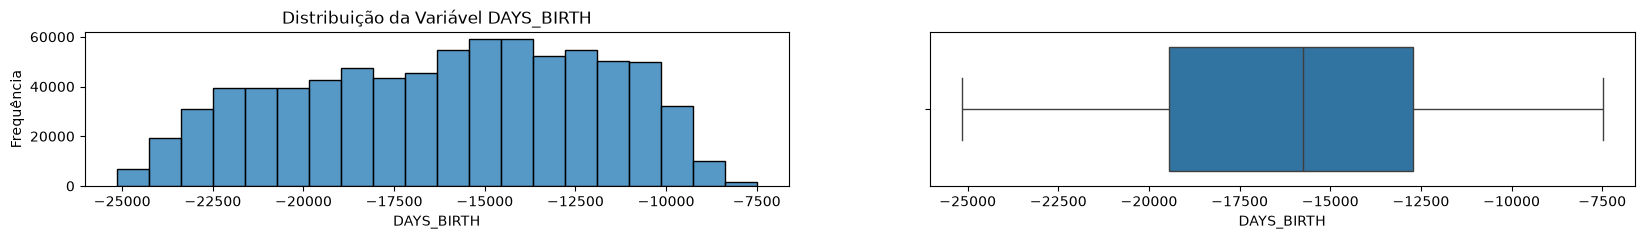

In [247]:
# Plotando distribuição e boxplot da coluna DAYS_BIRTH

fig, axes = plt.subplots(1, 2, figsize=(20, 2))

sns.histplot(data=df.DAYS_BIRTH, bins=20, ax=axes[0])
axes[0].set_title('Distribuição da Variável DAYS_BIRTH')
axes[0].set_xlabel('DAYS_BIRTH')
axes[0].set_ylabel('Frequência')

sns.boxplot(x='DAYS_BIRTH', data=df, ax=axes[1])    

plt.show()

**Interpretação**

Não há outliers.
Dados bem distribuídos
________________________________________________________________________________________________________________________________

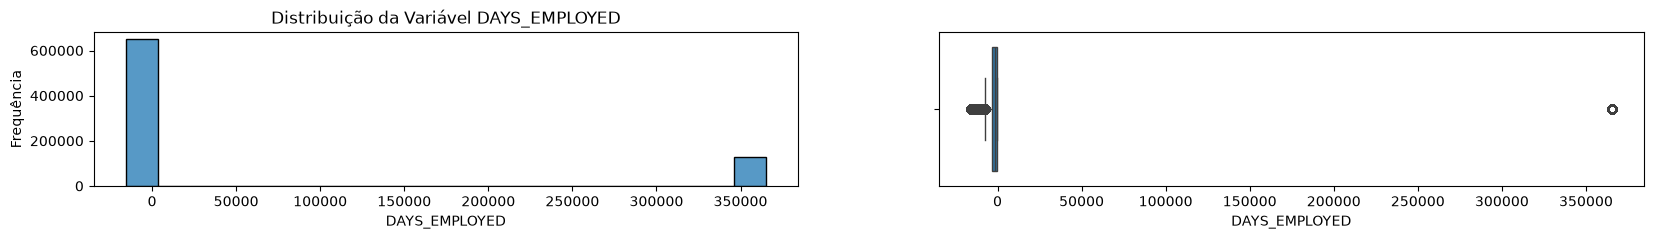

In [248]:
# Plotando distribuição e boxplot da coluna DAYS_EMPLOYED

fig, axes = plt.subplots(1, 2, figsize=(20, 2))

sns.histplot(data=df.DAYS_EMPLOYED, bins=20, ax=axes[0])
axes[0].set_title('Distribuição da Variável DAYS_EMPLOYED')
axes[0].set_xlabel('DAYS_EMPLOYED')
axes[0].set_ylabel('Frequência')

sns.boxplot(x='DAYS_EMPLOYED', data=df, ax=axes[1])    

plt.show()

**Interpretação**

Há dados bem extremos.
________________________________________________________________________________________________________________________________

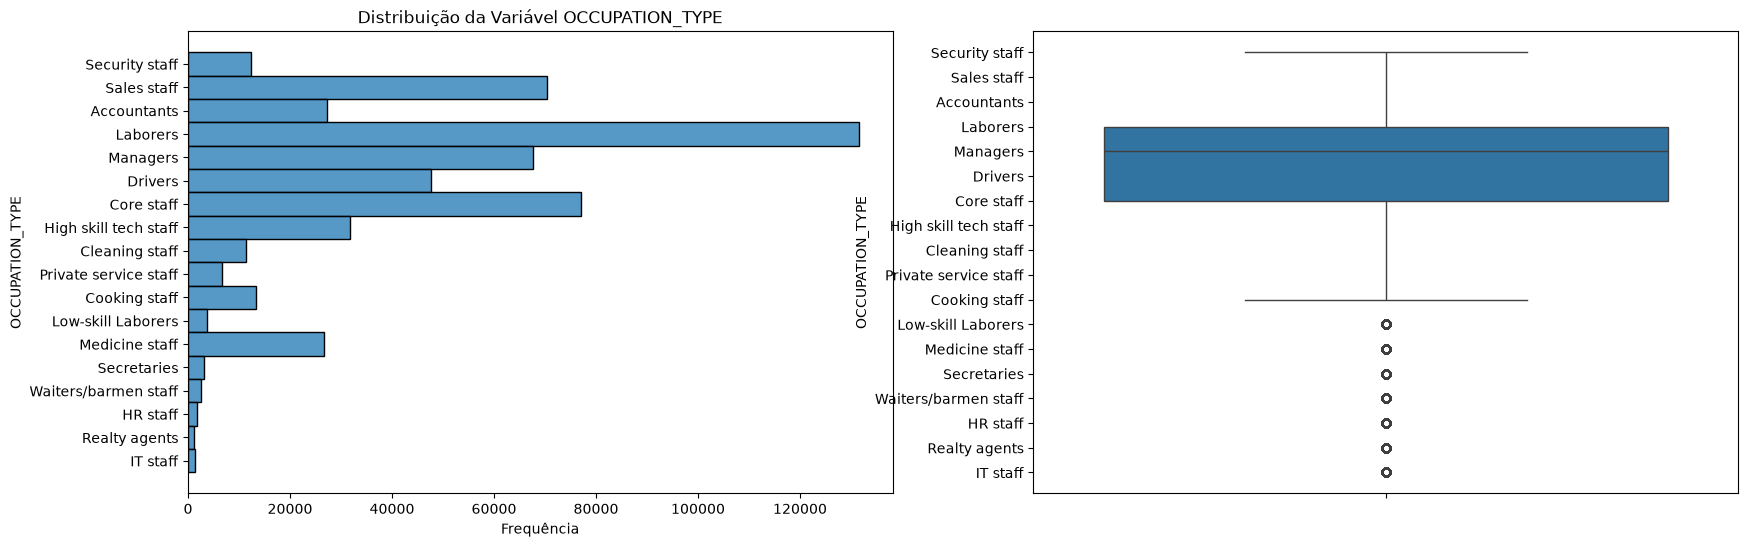

In [249]:
# Plotando distribuição e boxplot da coluna OCCUPATION_TYPE

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

sns.histplot(y=df.OCCUPATION_TYPE, bins=20, ax=axes[0])
axes[0].set_title('Distribuição da Variável OCCUPATION_TYPE')
axes[0].set_ylabel('OCCUPATION_TYPE')
axes[0].set_xlabel('Frequência')

sns.boxplot(y='OCCUPATION_TYPE', data=df, ax=axes[1])    

plt.show()

**Interpretação**

Há outliers, mas não se sabe ainda se podemos exluí-los
________________________________________________________________________________________________________________________________

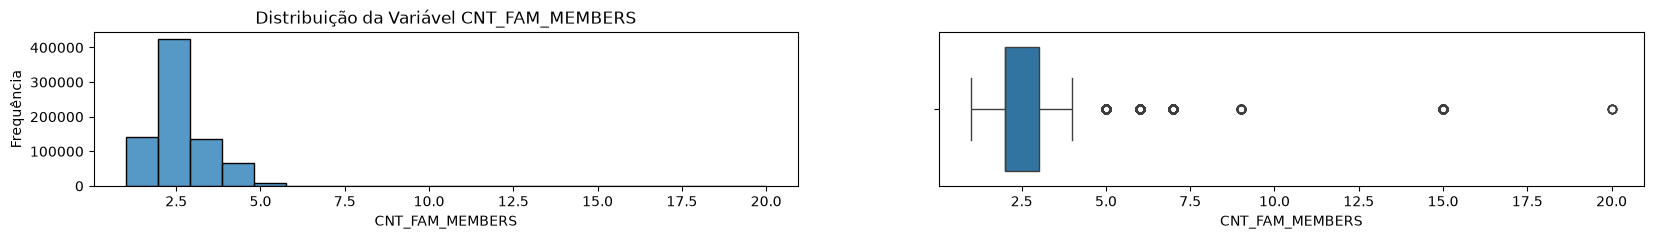

In [250]:
# Plotando distribuição e boxplot da coluna CNT_FAM_MEMBERS

fig, axes = plt.subplots(1, 2, figsize=(20, 2))

sns.histplot(data=df.CNT_FAM_MEMBERS, bins=20, ax=axes[0])
axes[0].set_title('Distribuição da Variável CNT_FAM_MEMBERS')
axes[0].set_xlabel('CNT_FAM_MEMBERS')
axes[0].set_ylabel('Frequência')

sns.boxplot(x='CNT_FAM_MEMBERS', data=df, ax=axes[1])    

plt.show()

**Interpretação**

Gráfico mostra assimetria à direita, com mais dados localizados na parte esquerda do gráfico.

Há outliers, porém não se sabe ainda se pode descartá-los ou não.
________________________________________________________________________________________________________________________________

Text(0.5, 1.0, 'Distribuição da Variável COMPLIANCE')

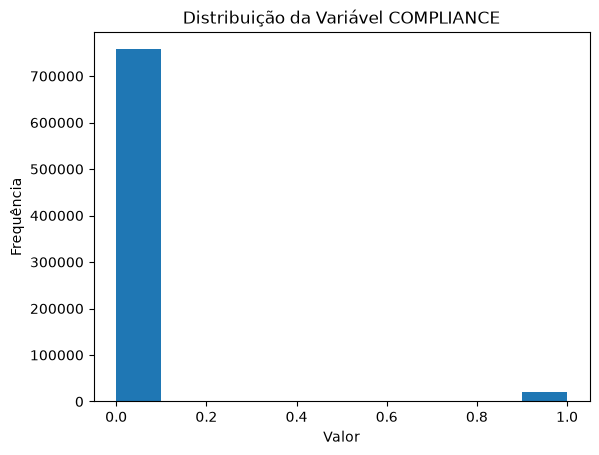

In [251]:
# Plotando distribuição da coluna COMPLIANCE

plt.hist(df.COMPLIANCE)
plt.ylabel('Frequência')
plt.xlabel('Valor')
plt.title('Distribuição da Variável COMPLIANCE')

**Interpretação**

Gráfico mostra que há mais de uma classe que de outra.
________________________________________________________________________________________________________________________________

## 3. Correlações

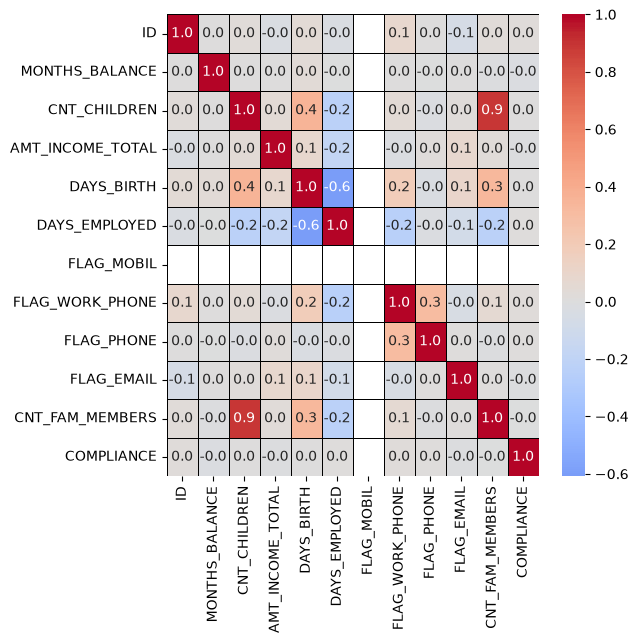

                   ID  MONTHS_BALANCE  CNT_CHILDREN  AMT_INCOME_TOTAL  \
ID                1.0             0.0           0.0              -0.0   
MONTHS_BALANCE    0.0             1.0           0.0               0.0   
CNT_CHILDREN      0.0             0.0           1.0               0.0   
AMT_INCOME_TOTAL -0.0             0.0           0.0               1.0   
DAYS_BIRTH        0.0             0.0           0.4               0.1   
DAYS_EMPLOYED    -0.0            -0.0          -0.2              -0.2   
FLAG_MOBIL        NaN             NaN           NaN               NaN   
FLAG_WORK_PHONE   0.1             0.0           0.0              -0.0   
FLAG_PHONE        0.0            -0.0          -0.0               0.0   
FLAG_EMAIL       -0.1             0.0           0.0               0.1   
CNT_FAM_MEMBERS   0.0            -0.0           0.9               0.0   
COMPLIANCE        0.0            -0.0           0.0              -0.0   

                  DAYS_BIRTH  DAYS_EMPLOYED  FLAG_

In [252]:
# Plotando a matriz de correlação

plt.figure(figsize=(6, 6))
matriz_corr = df.corr(numeric_only=True)
sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", fmt=".1f", center=0, linewidths=0.5, linecolor='black')
plt.show()

print(round(matriz_corr,1))


**Interpretação**

--

**90% de correlação:**

*CNT_FAM_MEMBERS e CNT_CHILDREN*

Forte correlação positiva, uma vez que uma depende da outra.

--

**60 % de correlação:**

*DAYS_BIRTH e DAYS_EMPLOYED*

Forte correlação negativa.

Ambas registram dias de forma regressiva (valores negativos contados a partir da data atual).

Reflete a tendência de pessoas mais velhas apresentarem maior tempo de serviço/carreira.

--

**40% de correlação:**


*CODE_GENDER e FLAG_OWN_CAR:*

Correlação positiva moderada.

Mostra maior proporção de posse de automóvel entre os clientes do gênero masculino.

|

*CNT_CHILDREN e DAYS_BIRTH*

Correlação positiva moderada.
Clientes em faixas etárias mais jovens (dias negativos mais próximos de zero) possuem maior número médio de filhos cadastrados.

--

**30% de correlação:**


*FLAG_WORK_PHONE e FLAG_PHONE:*

Correlação positiva moderada.

Clientes com telefone comercial tendem a cadastrar também um telefone fixo de contato.

|

*CNT_FAM_MEMBERS e DAYS_BIRTH*

Correlação positiva moderada.

Clientes em faixas etárias mais jovens (dias negativos mais próximos de zero) possuem maior número de membros familiares.
________________________________________________________________________________________________________________________________

## 4. Outliers

In [253]:
# Detectando os outliers usando o método do IQR (Interquartile Range) para as colunas numéricas:

df_outliers = []

for col in df.select_dtypes(include=['float64', 'int64']).columns:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
  count = len(outliers)
  pct = (count / len(df)) * 100

  df_outliers.append({
        'Coluna': col,
        'Mínimo': df[col].min(),
        'Q1 (25%)': Q1,
        'Mediana': df[col].median(),
        'Q3 (75%)': Q3,
        'Máximo': df[col].max(),
        'Limite Inf': lower_bound,
        'Limite Sup': upper_bound,
        'Qtd Outliers': count,
        '% Outliers': round(pct, 2),
        'Média': df[col].mean().round(2)
    })

# Colocando em um dataframe
df_outliers = pd.DataFrame(df_outliers) 

# Mostrando apenas as colunas com outliers maiores que 0
df_outliers[df_outliers['Qtd Outliers'] > 0]

,Coluna,Mínimo,Q1 (25%),Mediana,Q3 (75%),Máximo,Limite Inf,Limite Sup,Qtd Outliers,% Outliers,Média
2,CNT_CHILDREN,0.0,0.0,0.0,1.0,19.0,-1.5,2.5,11039,1.42,0.43
3,AMT_INCOME_TOTAL,27000.0,121500.0,162000.0,225000.0,1575000.0,-33750.0,380250.0,33987,4.37,188534.80
5,DAYS_EMPLOYED,-15713.0,-3292.0,-1682.0,-431.0,365243.0,-7583.5,3860.5,163348,21.00,57775.83
7,FLAG_WORK_PHONE,0.0,0.0,0.0,0.0,1.0,0.0,0.0,180288,23.18,0.23
9,FLAG_EMAIL,0.0,0.0,0.0,0.0,1.0,0.0,0.0,71297,9.17,0.09
10,CNT_FAM_MEMBERS,1.0,2.0,2.0,3.0,20.0,0.5,4.5,10631,1.37,2.21
11,COMPLIANCE,0.0,0.0,0.0,0.0,1.0,0.0,0.0,20565,2.64,0.03


**Interpretação**

*CNT_CHILDREN, CNT_FAM_MEMBERS e FLAG_EMAIL*

Baixa porcentagem de outliers.

Não há necessidade de exclusão, pois esses dados não afetarão a análise.

Serão mantidos.

|

*AMT_INCOME_TOTAL*

Ainda é umam porcentagem pequena em reação ao total de dados.

Dependendo do modelo, será necessário tratar.

Por enquanto serão mantidos e serão tratados no momento necessário.

|

*DAYS_EMPLOYED*

Alta porcentagem de outliers. Apresenta valor muito alto para máximo.

Serão tratados antes de realizar os treinamentos, pois pode afetar a análise.

|

*FLAG_WORK_PHONE*

Alta porcentagem de outiers, porém são dados necessários.

Serão mantidos.

Não há necessidade de tratamento.

---


## 5. Balanceamento de classes

In [254]:
df[TARGET].value_counts(normalize=True)

COMPLIANCE
0    0.973557
1    0.026443
Name: proportion, dtype: float64

**Interpretação:**

Há um claro desbalanceamento das classes.

Isso pode enviezar os modelos, portanto, será necessário efetuar um balanceamento.

---

## 6. Síntese da EDA

_Amarre os achados em uma narrativa única — é ela que vira o storytelling da apresentação._

In [255]:
# Salvando o dataframe
df.to_csv('../data/raw/df.csv', index=False)